In [1]:
print("hello")

hello


In [2]:
import torch
print(torch.__version__)
print(torch.cuda.is_available())

2.5.1+cu121
True


In [4]:
import torch
import pandas as pd
from transformers import pipeline

print("Torch version:", torch.__version__)
print("CUDA available:", torch.cuda.is_available())
if torch.cuda.is_available():
    print("GPU:", torch.cuda.get_device_name(0))

classifier = pipeline(
    "text-classification",
    model="distilbert-base-uncased-finetuned-sst-2-english",
    device=0 if torch.cuda.is_available() else -1
)

texts = [
    "I am really frustrated because my refund still has not arrived.",
    "Thanks, the issue is fixed now.",
    "I need help logging into my account."
]

results = classifier(texts)
df = pd.DataFrame({"text": texts, "prediction": results})
df

Torch version: 2.5.1+cu121
CUDA available: True
GPU: NVIDIA GeForce RTX 4050 Laptop GPU


Loading weights:   0%|          | 0/104 [00:00<?, ?it/s]

tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

,text,prediction
0,I am really frustrated because my refund still...,"{'label': 'NEGATIVE', 'score': 0.9996629953384..."
1,"Thanks, the issue is fixed now.","{'label': 'POSITIVE', 'score': 0.9990078806877..."
2,I need help logging into my account.,"{'label': 'NEGATIVE', 'score': 0.9993448853492..."


Loading weights:   0%|          | 0/104 [00:00<?, ?it/s]

Loading local CSV dataset from ../data/customer_support_data.csv...
Running AI Emotion Detection...


,text,ai_prediction,ai_confidence
0,"Hello, my SSO is not working as expected. tyug...",negative,0.998
1,I'm sorry about the trouble. Let me check your...,negative,0.999
2,It’s urgent. Please expedite. yapinekjmk bugnl...,negative,0.982
3,"Main abhi verify kar rahi/raha hoon, kindly wa...",negative,0.997
4,"Got it. I’ve retried, and it works now. qtr qn...",negative,0.993
5,"Main abhi verify kar rahi/raha hoon, kindly wa...",negative,0.996
6,"Thanks, that helps. odt gpysmjnn fcuyb ros mdk...",negative,0.830
7,I understand this is frustrating. I'm investig...,negative,0.997
8,"Got it. I’ve retried, and it works now. uftug ...",negative,0.993
9,I understand this is frustrating. I'm investig...,negative,0.998


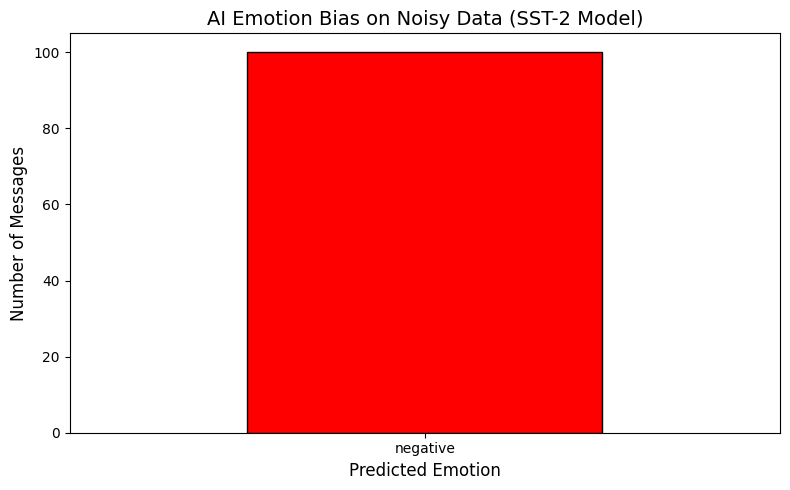

In [7]:
import pandas as pd
import matplotlib.pyplot as plt
from transformers import pipeline

classifier = pipeline(
    "text-classification",
    model="distilbert-base-uncased-finetuned-sst-2-english",
    device=0 
)

file_path = "../data/customer_support_data.csv" 
print(f"Loading local CSV dataset from {file_path}...")

df = pd.read_csv(file_path, nrows=100, on_bad_lines="skip", encoding="utf-8")
text_column_name = 'text' 

print("Running AI Emotion Detection...")
texts = df[text_column_name].astype(str).tolist()
predictions = classifier(texts)

df['ai_prediction'] = [pred['label'].lower() for pred in predictions]
df['ai_confidence'] = [round(pred['score'], 3) for pred in predictions]

display(df[[text_column_name, 'ai_prediction', 'ai_confidence']].head(10))

emotion_counts = df['ai_prediction'].value_counts()
colors = ['red' if label == 'negative' else 'green' for label in emotion_counts.index]

plt.figure(figsize=(8, 5))
emotion_counts.plot(kind='bar', color=colors, edgecolor='black')
plt.title('AI Emotion Bias on Noisy Data (SST-2 Model)', fontsize=14)
plt.xlabel('Predicted Emotion', fontsize=12)
plt.ylabel('Number of Messages', fontsize=12)
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

In [ ]:
import pandas as pd
from transformers import pipeline

classifier = pipeline(
    "text-classification",
    model="distilbert-base-uncased-finetuned-sst-2-english",
    device=0
)

file_path = "../data/customer_support_data.csv" 
print(f"Loading a pool of 5000 messages from {file_path}...")

df_pool = pd.read_csv(file_path, nrows=5000, on_bad_lines="skip", encoding="utf-8")

df_random = df_pool.sample(n=10)

text_column_name = 'text' 

print("Running AI Emotion Detection on the random samples...")
texts = df_random[text_column_name].astype(str).tolist()

predictions = classifier(texts)

df_random['ai_prediction'] = [pred['label'].lower() for pred in predictions]
df_random['ai_confidence'] = [round(pred['score'], 3) for pred in predictions]

display(df_random[[text_column_name, 'ai_prediction', 'ai_confidence']])

Loading weights:   0%|          | 0/104 [00:00<?, ?it/s]

Loading a pool of 5000 messages from ../data/customer_support_data.csv...
Running AI Emotion Detection on the random samples...


,text,ai_prediction,ai_confidence
4827,I can help with that. May I have the registere...,negative,0.997
4660,Thanks for reaching out! I’m pulling up the de...,negative,0.974
2292,"Main abhi verify kar rahi/raha hoon, kindly wa...",negative,0.996
2327,"Thanks, that helps. nzcucrggko zexihwtfc uoufa...",negative,0.728
4629,"Thanks, that helps. choxxgo biymv qcqdwcjm xpi...",negative,0.541
980,I'm sorry about the trouble. Let me check your...,negative,0.999
541,It’s urgent. Please expedite. ipxwpctnv cfqtpp...,negative,0.980
4170,Thanks for reaching out! I’m pulling up the de...,negative,0.992
451,It’s urgent. Please expedite. bcykbnpczo fnaph...,negative,0.991
2471,I understand this is frustrating. I'm investig...,negative,0.997


Loading weights:   0%|          | 0/104 [00:00<?, ?it/s]

Loading a pool of 5000 messages from ../data/Bitext_Sample_Customer_Support_Training_Dataset_27K_responses-v11.csv...
Running AI Emotion Detection on the random samples...


,instruction,ai_prediction,ai_confidence
1501,modify order {{Order Number}},negative,0.972
2586,want assistance trying to change the shipping ...,negative,0.994
2653,there is an issue modifying the shipping address,negative,0.998
1055,correct purchase {{Order Number}},positive,0.992
705,I would like to cancel purchase {{Order Number}},negative,1.000
106,i do not know how to cancel order {{Order Numb...,negative,1.000
589,i want assistance to cancel order {{Order Numb...,negative,1.000
2468,i need help to change my shipping address,negative,1.000
2413,wanna know more about editing my shipping address,negative,0.999
1600,change order {{Order Number}},negative,0.905


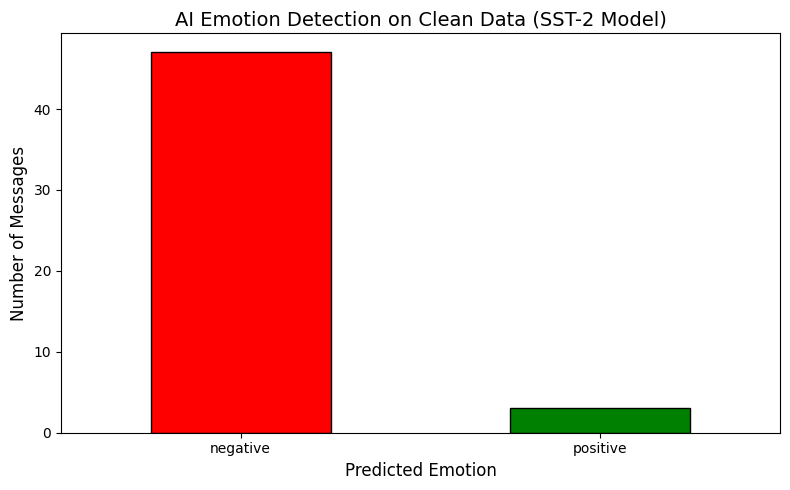

In [10]:
import pandas as pd
import matplotlib.pyplot as plt
from transformers import pipeline

classifier = pipeline(
    "text-classification",
    model="distilbert-base-uncased-finetuned-sst-2-english",
    device=0
)

file_path = "../data/Bitext_Sample_Customer_Support_Training_Dataset_27K_responses-v11.csv" 
print(f"Loading a pool of 5000 messages from {file_path}...")

df_pool = pd.read_csv(file_path, nrows=5000, on_bad_lines="skip", encoding="utf-8")
df_random = df_pool.sample(n=50, random_state=42)

text_column_name = 'instruction' 

print("Running AI Emotion Detection on the random samples...")
texts = df_random[text_column_name].astype(str).tolist()
predictions = classifier(texts)

df_random['ai_prediction'] = [pred['label'].lower() for pred in predictions]
df_random['ai_confidence'] = [round(pred['score'], 3) for pred in predictions]

display(df_random[[text_column_name, 'ai_prediction', 'ai_confidence']].head(10))

emotion_counts = df_random['ai_prediction'].value_counts()
colors = ['red' if label == 'negative' else 'green' for label in emotion_counts.index]

plt.figure(figsize=(8, 5))
emotion_counts.plot(kind='bar', color=colors, edgecolor='black')
plt.title('AI Emotion Detection on Clean Data (SST-2 Model)', fontsize=14)
plt.xlabel('Predicted Emotion', fontsize=12)
plt.ylabel('Number of Messages', fontsize=12)
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

Loading AI model from: c:\Users\Farhan Zariwala\Documents\UFV\winter 2026\comp 361\Final Project\Project\local_model
Loading data from: c:\Users\Farhan Zariwala\Documents\UFV\winter 2026\comp 361\Final Project\Project\data\Bitext_Sample_Customer_Support_Training_Dataset_27K_responses-v11.csv


Loading weights:   0%|          | 0/201 [00:00<?, ?it/s]

RobertaForSequenceClassification LOAD REPORT from: c:\Users\Farhan Zariwala\Documents\UFV\winter 2026\comp 361\Final Project\Project\local_model
Key                             | Status     |  | 
--------------------------------+------------+--+-
roberta.embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Analyzing 50 messages for complex emotions...


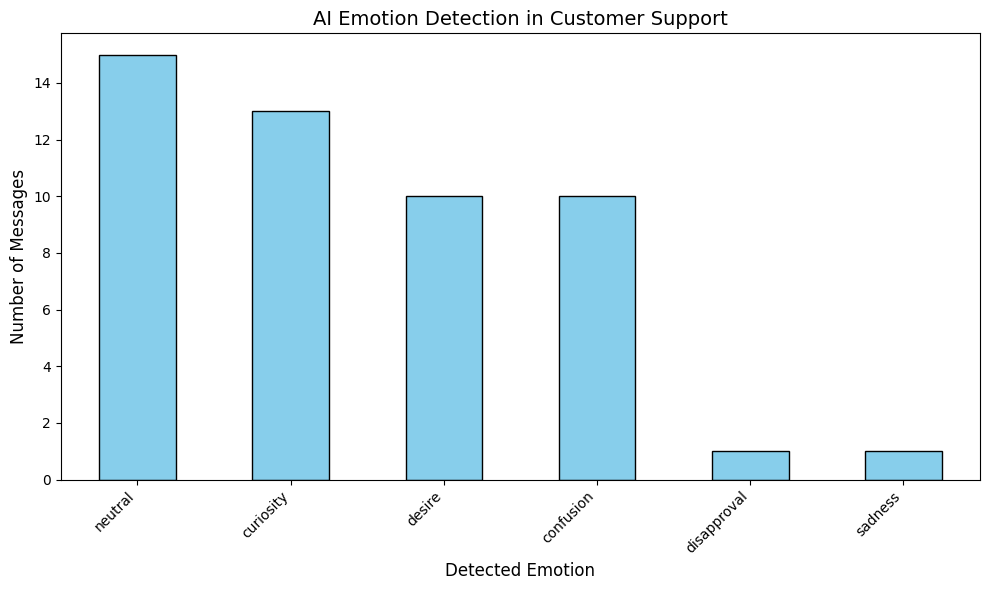

,instruction,emotion
9329,I can't talk with a human agent,disapproval
4160,I have got to locate hte bills from {{Person N...,neutral
18500,"I cannot pay, help me to inform of a problem w...",sadness
8840,I want help speaking to customer service,desire
5098,I try to see th accepted payment options,neutral
17250,where to sign up to the company nmewsletter,neutral
3589,I'd like to see the withdrwaal fee how can i d...,desire
9043,I want to speak with someone,desire
15800,can you help me getting bill #85632?,curiosity
4384,I don't know how to take a quick look at invoi...,confusion


In [ ]:
import os
import pandas as pd
import matplotlib.pyplot as plt
from transformers import pipeline


current_dir = os.getcwd()
if current_dir.endswith('notebooks'):
    project_root = os.path.dirname(current_dir)
else:
    project_root = current_dir

model_path = os.path.join(project_root, "local_model")
data_path = os.path.join(project_root, "data", "Bitext_Sample_Customer_Support_Training_Dataset_27K_responses-v11.csv")

print(f"Loading AI model from: {model_path}")
print(f"Loading data from: {data_path}")

emotion_classifier = pipeline(
    "text-classification",
    model=model_path, 
    tokenizer=model_path,
    device=0 
)

df_pool = pd.read_csv(data_path, encoding="utf-8")

df_sample = df_pool.sample(n=50, random_state=42)
texts = df_sample['instruction'].astype(str).tolist()

print("Analyzing 50 messages for complex emotions...")
predictions = emotion_classifier(texts)

df_sample['emotion'] = [pred['label'] for pred in predictions]

emotion_counts = df_sample['emotion'].value_counts()

plt.figure(figsize=(10, 6))
emotion_counts.plot(kind='bar', color='skyblue', edgecolor='black')
plt.title('AI Emotion Detection in Customer Support', fontsize=14)
plt.xlabel('Detected Emotion', fontsize=12)
plt.ylabel('Number of Messages', fontsize=12)
plt.xticks(rotation=45, ha='right')
plt.tight_layout()

plt.show()
display(df_sample[['instruction', 'emotion']].head(10))

Loading local multi-emotion AI model from: c:\Users\Farhan Zariwala\Documents\UFV\winter 2026\comp 361\Final Project\Project\local_model


Loading weights:   0%|          | 0/201 [00:00<?, ?it/s]

RobertaForSequenceClassification LOAD REPORT from: c:\Users\Farhan Zariwala\Documents\UFV\winter 2026\comp 361\Final Project\Project\local_model
Key                             | Status     |  | 
--------------------------------+------------+--+-
roberta.embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Loading bad dataset from: c:\Users\Farhan Zariwala\Documents\UFV\winter 2026\comp 361\Final Project\Project\data\customer_support_data.csv
Analyzing 50 noisy messages for complex emotions...


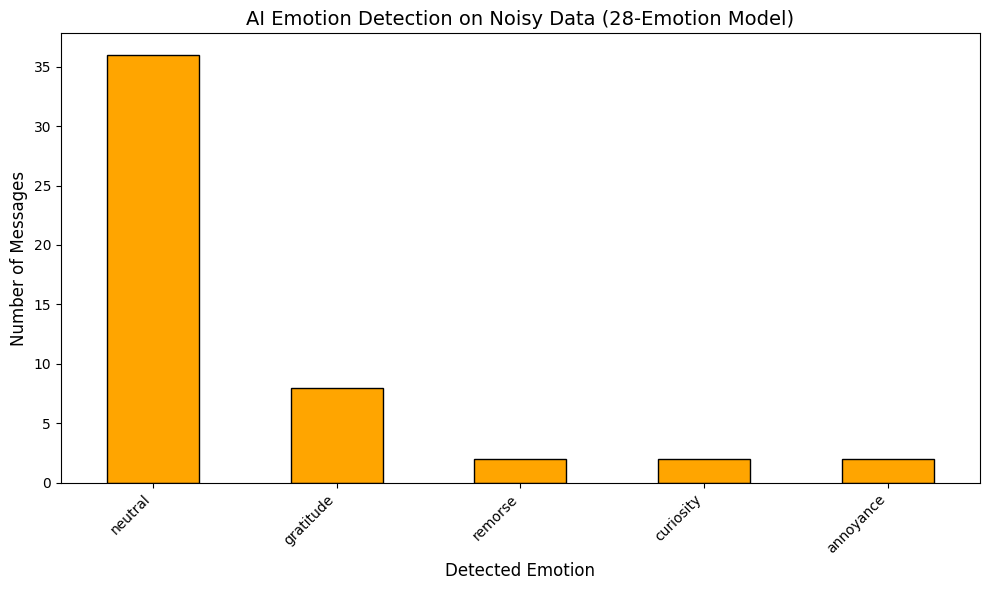

,text,emotion
1501,I have issued a refund. You’ll see it in 3-5 b...,neutral
2586,I'm sorry about the trouble. Let me check your...,remorse
2653,I can help with that. May I have the registere...,curiosity
1055,I can help with that. May I have the registere...,curiosity
705,I have applied the coupon manually and adjuste...,neutral
106,Still not fixed. Can you escalate? fjzdjocgm h...,neutral
589,I have issued a refund. You’ll see it in 3-5 b...,neutral
2468,"Thoda jaldi please, flight in 2 hours. scjeght...",neutral
2413,"Got it. I’ve retried, and it works now. weqfar...",neutral
1600,"Got it. I’ve retried, and it works now. gztpky...",neutral


In [11]:
import os
import pandas as pd
import matplotlib.pyplot as plt
from transformers import pipeline

current_dir = os.getcwd()
if current_dir.endswith('notebooks'):
    project_root = os.path.dirname(current_dir)
else:
    project_root = current_dir

model_path = os.path.join(project_root, "local_model")
data_path = os.path.join(project_root, "data", "customer_support_data.csv")

print(f"Loading local multi-emotion AI model from: {model_path}")

emotion_classifier = pipeline(
    "text-classification",
    model=model_path, 
    tokenizer=model_path,
    device=0 
)

print(f"Loading bad dataset from: {data_path}")
df_pool = pd.read_csv(data_path, nrows=5000, on_bad_lines="skip", encoding="utf-8")

df_sample = df_pool.sample(n=50, random_state=42)
text_column_name = 'text'

print("Analyzing 50 noisy messages for complex emotions...")
texts = df_sample[text_column_name].astype(str).tolist()
predictions = emotion_classifier(texts)

df_sample['emotion'] = [pred['label'] for pred in predictions]

emotion_counts = df_sample['emotion'].value_counts()

plt.figure(figsize=(10, 6))
emotion_counts.plot(kind='bar', color='orange', edgecolor='black')
plt.title('AI Emotion Detection on Noisy Data (28-Emotion Model)', fontsize=14)
plt.xlabel('Detected Emotion', fontsize=12)
plt.ylabel('Number of Messages', fontsize=12)
plt.xticks(rotation=45, ha='right')
plt.tight_layout()

plt.show()
display(df_sample[[text_column_name, 'emotion']].head(10))